<a href="https://colab.research.google.com/github/donatelk/kgdneuro265/blob/main/Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Kelsey Donatelli

Neuro 265

3/6/2026

In [1]:
#Import packages
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
#Upload data
patch_seq_url= 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded.csv'
patch_seq= pd.read_csv(patch_seq_url)

Text(0, 0.5, 'Number of Cells')

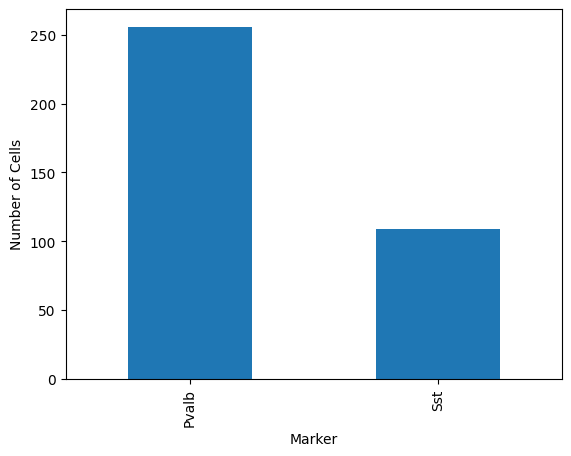

In [3]:
#Graph of value counts
patch_seq['Marker'].value_counts().plot(kind='bar')
plt.xlabel('Marker')
plt.ylabel('Number of Cells')

Text(0, 0.5, 'Number of Cells')

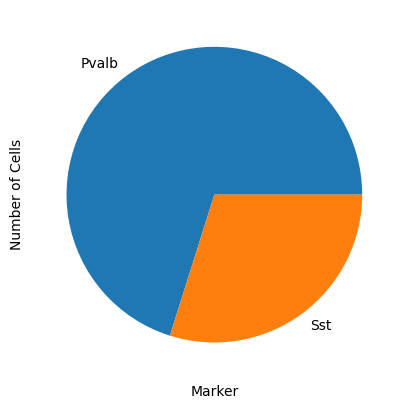

In [4]:
#Pie chart of value counts
patch_seq['Marker'].value_counts().plot(kind='pie')
plt.xlabel('Marker')
plt.ylabel('Number of Cells')

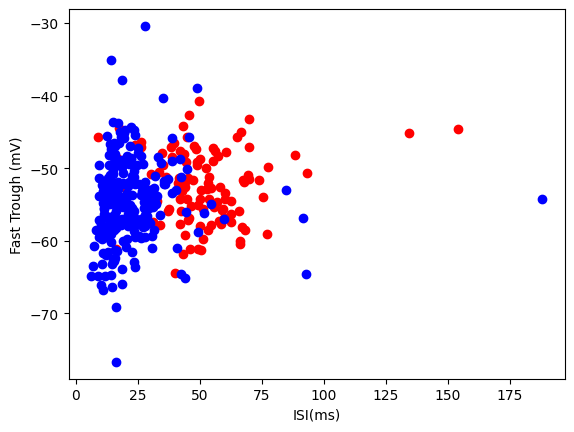

In [5]:
#Scatter plot of ISI and Fast Trough values
patch_length = len(patch_seq)

for i in range(patch_length):
  if patch_seq.iloc[i,2] == 'Sst':
    plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "red")
  elif patch_seq.iloc[i,2] == 'Pvalb':
    plt.scatter(patch_seq.iloc[i,0], patch_seq.iloc[i,1], color = 'blue')

plt.xlabel('ISI(ms)')
plt.ylabel('Fast Trough (mV)')

plt.show()

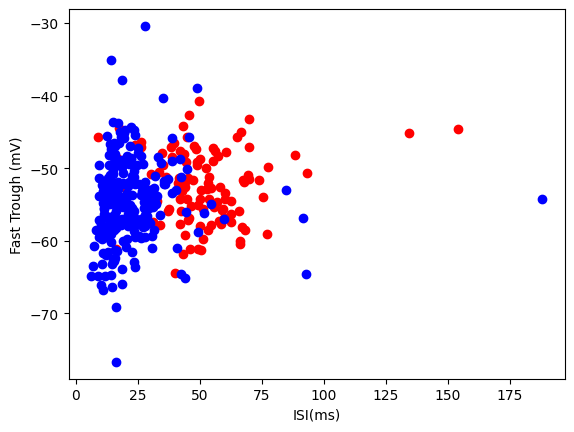

In [6]:
#Create a function for the scatter plot
def patchScatter():
  """
  Makes a scatter plot of ISI and Fast Trough values, with Sst neurons in red and Pvalb neurons in blue
  """
  patch_length = len(patch_seq)

  for i in range(patch_length):
    if patch_seq.iloc[i,2] == 'Sst':
      plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "red")
    elif patch_seq.iloc[i,2] == 'Pvalb':
      plt.scatter(patch_seq.iloc[i,0], patch_seq.iloc[i,1], color = 'blue')

  plt.xlabel('ISI(ms)')
  plt.ylabel('Fast Trough (mV)')

  plt.show()

#Use the function
patchScatter()

In [7]:
#Find mean, SD, and range of Fast Trough for Sst and Pvalb neurons
patch_seq.groupby('Marker')['Fast_Trough'].describe()

,count,mean,std,min,25%,50%,75%,max
Marker,,,,,,,,
Pvalb,256.0,-54.548074,5.870670,-76.687508,-57.914063,-54.490629,-51.364065,-30.406252
Sst,109.0,-52.514968,4.958103,-64.375008,-55.931252,-52.568752,-48.500000,-40.781254


###Difference Between Sst and Pvalb neurons

Pvalb cells have a more negative undershoot following an action potential than Sst cells. However, Pvalb cells also seem to return back to resting state faster.

In [8]:
#The skewedness of Fast Trough for Sst and Pvalb neurons
patch_seq.groupby('Marker')['Fast_Trough'].skew()

,Fast_Trough
Marker,
Pvalb,0.19536
Sst,0.00125


###Skewedness for Fast Trough

Sst shows a normal distribution with a value between -0.5 and 0.5

Pvalb also shows a normal distribution with a value between -0.5 and 0.5

In [9]:
#The skewedness of ISI for Sst and Pvalb neurons
patch_seq.groupby('Marker')['ISI'].skew()

,ISI
Marker,
Pvalb,5.596386
Sst,1.857850


###Skewedness for ISI
Sst shows a skewed distribution with a value outside of -0.5 and 0.5

Pvalb also shows a skewed distribution with a value outside of -0.5 and 0.5

In [10]:
#T-test for Fast Trough
sst_neurons= patch_seq[patch_seq['Marker']== 'Sst']
pvalb_neurons= patch_seq[patch_seq['Marker']== 'Pvalb']

stats.ttest_ind(sst_neurons['Fast_Trough'], pvalb_neurons['Fast_Trough'])

TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))

###T-Test Results

The undershoot voltage does differ significantly between the two groups, with a pvalue less than 0.05.

In [12]:
#T-test for ISI
sst= sst_neurons['ISI'].dropna()
pvalb= pvalb_neurons['ISI'].dropna()

stats.ttest_ind(sst, pvalb)

TtestResult(statistic=np.float64(14.643966775010774), pvalue=np.float64(2.694292788633572e-38), df=np.float64(354.0))

###T-Test Results
The ISI values does differ significantly between the two groups, with a pvalue less than 0.05.